I0000 00:00:1782934766.406063  245838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782934766.406483  245838 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782934766.443142  245838 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782934767.385668  245838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Current working directory:
/home/aluoch/smart-waste-classifier/notebooks
Found 12259 files belonging to 10 classes.
Using 9808 files for training.
Found 12259 files belonging to 10 classes.
Using 2451 files for validation.


E0000 00:00:1782934768.423916  245838 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 104s 331ms/step - accuracy: 0.5548 - loss: 1.3133 - val_accuracy: 0.5977 - val_loss: 1.1822
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 101s 328ms/step - accuracy: 0.6662 - loss: 0.9997 - val_accuracy: 0.6671 - val_loss: 1.0153
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 109s 355ms/step - accuracy: 0.6963 - loss: 0.8970 - val_accuracy: 0.6410 - val_loss: 1.0609
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 101s 328ms/step - accuracy: 0.7278 - loss: 0.8016 - val_accuracy: 0.6430 - val_loss: 1.0679
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 101s 330ms/step - accuracy: 0.7501 - loss: 0.7403 - val_accuracy: 0.6871 - val_loss: 0.9604
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 101s 329ms/step - accuracy: 0.7619 - loss: 0.6879 - val_accuracy: 0.6928 - val_loss: 0.9238
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 336ms/step - accuracy: 0.7908 - loss: 0.6246 - val_accuracy: 0.6626 - val_loss: 1.0060
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 102s 333ms/step - accuracy: 0.8053 -

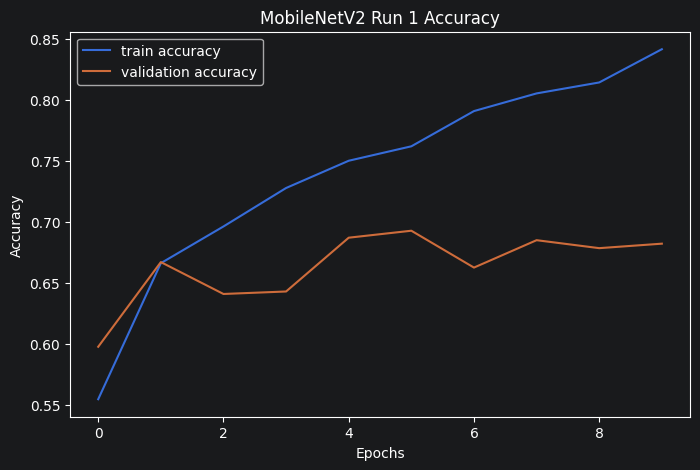

Saved MobileNet loss figure successfully!


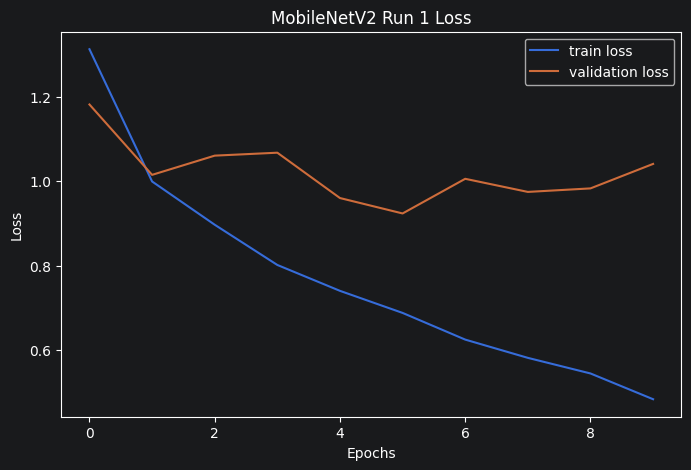

MobileNetV2 model saved successfully!


In [1]:
# Imports
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time

print("Current working directory:")
print(os.getcwd())

# Dataset loading
data_dir = "../data/standardized_256"

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Create output folders
os.makedirs("../models", exist_ok=True)
os.makedirs("../images", exist_ok=True)

# Load pretrained MobileNetV2 model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# Build MobileNetV2 model
model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Training timer
start_time = time.time()

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# End timer
end_time = time.time()

print("Training time:", end_time - start_time, "seconds")

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.title("MobileNetV2 Run 1 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../images/mobilenet_run1_accuracy.png")
print("Saved MobileNet accuracy image successfully!")

plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.title("MobileNetV2 Run 1 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../images/mobilenet_run1_loss.png")
print("Saved MobileNet loss figure successfully!")

plt.show()

# Save model
model.save("../models/mobilenet_run1.keras")
print("MobileNetV2 model saved successfully!")